# VinDatathon 2026 - Part3: Sales Forecasting Pipeline
**Goal:** Predict daily `Revenue` and `COGS` **from 2023-01-01 to 2024-07-01** (548 days)  
**Training data:** `sales.csv` **from 2012-07-04 to 2022-12-31** (3,833 days)  
**Metric:** `MAE` + `RMSE` + `R²` averaged over both targets  


## Pipeline Architecture

```
sales.csv  (2012–2022, 3,833 days)
    │
    ├─► Section 3: Feature Engineering  (~80 calendar-only features)
    │
    ├─► Section 4: Four Base Models (all log-space: log(y) in → exp() out)
    │       M1: Ridge (z-scored Fourier anchor, α=3.0)
    │       M2: LightGBM base (high-era sample weights 2014–2018)
    │       M3: Prophet (multiplicative, post-2020 only, promo regressors)
    │       M4: Chronos t5-large (rolling chunk=64, ns=20, level-calibrated)
    │
    ├─► Section 5: Q-Specialist LightGBM (4 quarters × 2 targets = 8 models)
    │       Each specialist: base weights × 2.0 boost on target quarter
    │       Composed: each test day uses its quarter's specialist
    │
    ├─► Section 6: 3-Tier Ensemble
    │       Tier 1  LGB_blend = 0.60×Q-Spec + 0.40×LGB_base
    │       Tier 2  raw = 0.15·Chronos + 0.10·Ridge + 0.75·LGB_blend
    │               ("no_prophet" config — LB best, Prophet excluded)
    │       Tier 3  final_rev = CR × raw_rev,  final_cog = CC × raw_cog
    │
    └─► Section 7: COGS Margin Fix + Submission Export
            Per-quarter β-blend (β=0.30) + COGS mean preservation
            CR/CC sweep across 9 files (CR ∈ {1.28,1.30,1.32}, CC=1.35)
```

## 1 — Imports & Config

In [157]:
!pip install lightgbm prophet -q
!pip install chronos-forecasting --no-deps -q
!pip install einops -q
!pip install shap -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import torch
from chronos import ChronosPipeline
from prophet import Prophet

from pathlib import Path

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('SHAP not installed - install with: pip install shap')

# This block seeds every library simultaneously for full reproducibility
# LGB      : controlled via seed=42 in LGB_PARAMS
# Prophet  : np.random.seed() before each .fit()
# Chronos  : torch.manual_seed() before each pipeline call
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# Enforce deterministic CUDA ops
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Auto-detect Kaggle vs local layout.
# Local repo: notebooks/ sits next to data/ at the repo root, so DATA_DIR = ../data
# and OUT_DIR = .. so submission.csv lands at the root alongside the dataset.
KAGGLE_DATA = Path('/kaggle/input/datasets/cahoivuotthac/datathon2026')
if KAGGLE_DATA.exists():
    DATA_DIR = KAGGLE_DATA
    OUT_DIR  = Path('/kaggle/working')
else:
    DATA_DIR = Path('../data')
    OUT_DIR  = Path('..')
OUT_DIR.mkdir(exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'SEED    : {SEED}')
print(f'SHAP    : {"available" if SHAP_OK else "not installed"}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'OUT_DIR : {OUT_DIR}')

## 2 — Load & Inspect Data

We load `sales.csv` (3,833 daily rows) and perform a quick EDA confirming the two
key structural patterns that drive the modelling strategy: \
(1) **the seasonal shape** is
stable across years while **the level drifts** across regimes \
(2) **Q3 margin spikes
in odd years** due to the Urban Blowout campaign

In [159]:
sales = pd.read_csv(DATA_DIR / 'sales.csv', parse_dates=['Date'])
sales.columns = sales.columns.str.strip()
sales['Y'] = sales['Date'].dt.year
sales['M'] = sales['Date'].dt.month
sales['Q'] = sales['Date'].dt.quarter

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
HORIZON    = len(test_dates)

print(f'Training rows : {len(sales):,} ({sales.Date.min().date()} → {sales.Date.max().date()})')
print(f'Test rows     : {HORIZON:,}    ({test_dates[0].date()} → {test_dates[-1].date()})')
print()
print('Annual Revenue & COGS:')
print(sales.groupby('Y')[['Revenue','COGS']].sum().to_string())

Training rows : 3,833 (2012-07-04 → 2022-12-31)
Test rows     : 548    (2023-01-01 → 2024-07-01)

Annual Revenue & COGS:
           Revenue          COGS
Y                               
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


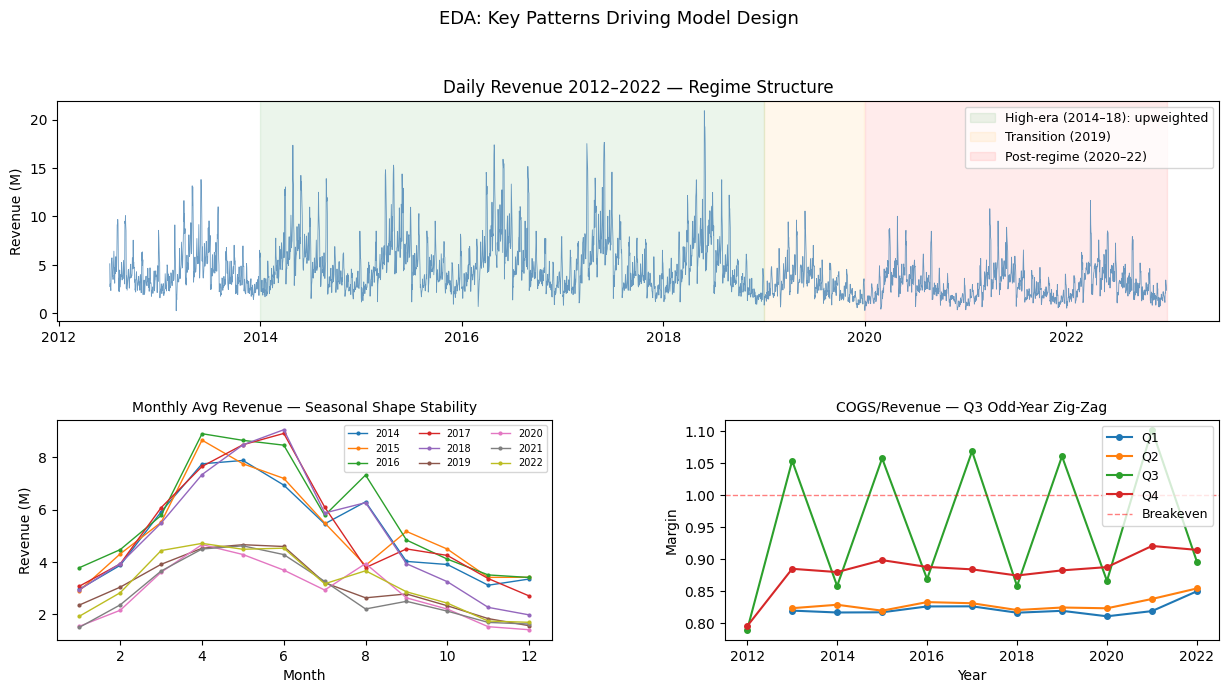

In [160]:
fig = plt.figure(figsize=(15, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sales.Date, sales.Revenue/1e6, lw=0.6, color='steelblue', alpha=0.8)
for span, color, label in [
    (('2014-01-01','2018-12-31'), 'green',  'High-era (2014–18): upweighted'),
    (('2019-01-01','2019-12-31'), 'orange', 'Transition (2019)'),
    (('2020-01-01','2022-12-31'), 'red',    'Post-regime (2020–22)'),
]:
    ax1.axvspan(pd.Timestamp(span[0]), pd.Timestamp(span[1]),
                alpha=0.08, color=color, label=label)
ax1.set_title('Daily Revenue 2012–2022 — Regime Structure', fontsize=12)
ax1.set_ylabel('Revenue (M)'); ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
for yr in range(2014, 2023):
    sub = sales[sales.Y==yr].groupby('M')['Revenue'].mean()/1e6
    ax2.plot(sub.index, sub.values, marker='o', markersize=2, lw=1, label=str(yr))
ax2.set_title('Monthly Avg Revenue — Seasonal Shape Stability', fontsize=10)
ax2.set_xlabel('Month'); ax2.set_ylabel('Revenue (M)')
ax2.legend(fontsize=7, ncol=3)

ax3 = fig.add_subplot(gs[1, 1])
sales['margin'] = sales['COGS']/sales['Revenue']
qm = sales.groupby(['Y','Q'])['margin'].mean().reset_index()
for q in [1,2,3,4]:
    sub = qm[qm.Q==q]
    ax3.plot(sub.Y, sub.margin, marker='o', markersize=4, lw=1.5, label=f'Q{q}')
ax3.axhline(1.0, ls='--', color='red', lw=1, alpha=0.5, label='Breakeven')
ax3.set_title('COGS/Revenue — Q3 Odd-Year Zig-Zag', fontsize=10)
ax3.set_xlabel('Year'); ax3.set_ylabel('Margin'); ax3.legend(fontsize=9)

plt.suptitle('EDA: Key Patterns Driving Model Design', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3 — Feature Engineering

All features are **calendar-only** which are computable from the date alone with no
reference to past target values. This is mandatory: with an 18-month forecast
horizon, lag features (`yt-1`, `yt-7`, `yt-365`) are unavailable for the vast majority
of the test window.

| Feature group | Count | Rationale |
|---|---|---|
| Fourier annual k=1-5 | 10 | Captures the 5 dominant harmonics of yearly seasonality |
| Fourier weekly k=1-2 | 4 | Weekday vs weekend pattern |
| Fourier intra-month k=1-2 | 4 | Day-of-month spike encoding |
| Edge-of-month / start-of-month | 9 | Revenue spikes days 1-3 and 28-31 |
| Promo windows (6 campaigns) | 24 | Extracted from promotions.csv |
| Regime dummies + trend | 4 | Structural breaks at 2019 and 2020 |
| Calendar basics | 10 | Year, month, day, DOW, DOY, quarter, etc. |
| Odd/even year | 1 | Urban Blowout & Rural Special run odd years only |
| **Total** | **~83** | |
<!-- | Tết proximity | 6 | Tết shifts each year - fixed month features miss it | -->
<!-- | VN public holidays + Black Friday | 11 | Step-change demand on fixed dates | -->


### Build features

In [161]:
import re
from scipy import stats as scipy_stats

promos = pd.read_csv(DATA_DIR / "promotions.csv")

def build_promo_schedule_from_csv(promos_df):
    df = promos_df.copy()
    df['start_date'] = pd.to_datetime(df['start_date'])
    df['end_date']   = pd.to_datetime(df['end_date'])

    def to_base_name(name):
        name = re.sub(r'\b\d{4}\b', '', str(name))
        name = name.strip().lower()
        name = re.sub(r'\s+', '_', name)
        name = re.sub(r'[^a-z0-9_]', '', name)
        return name.strip('_')

    df['base_name'] = df['promo_name'].apply(to_base_name)
    df['year']      = df['start_date'].dt.year
    df['start_m']   = df['start_date'].dt.month
    df['start_d']   = df['start_date'].dt.day
    df['duration']  = (df['end_date'] - df['start_date']).dt.days

    schedule = []
    for base_name, group in df.groupby('base_name', sort=False):
        start_m  = int(scipy_stats.mode(group['start_m'], keepdims=True).mode[0])
        start_d  = int(scipy_stats.mode(group['start_d'], keepdims=True).mode[0])
        duration = int(scipy_stats.mode(group['duration'], keepdims=True).mode[0])

        promo_type = group['promo_type'].iloc[0]
        if promo_type == 'percentage':
            disc = float(group['discount_value'].mode()[0])
        else:
            disc = None 

        # Detect recurrence
        years = sorted(group['year'].unique())
        if len(years) >= 2 and all(y % 2 == 1 for y in years):
            recur = 'odd'
        elif len(years) >= 2 and all(y % 2 == 0 for y in years):
            recur = 'even'
        else:
            recur = True

        schedule.append((base_name, start_m, start_d, duration, disc, recur))

    return schedule

PROMO_SCHEDULE = build_promo_schedule_from_csv(promos)
PROMO_SCHEDULE

[('spring_sale', 3, 18, 30, 12.0, True),
 ('midyear_sale', 6, 23, 29, 18.0, True),
 ('fall_launch', 8, 30, 32, 10.0, True),
 ('yearend_sale', 11, 18, 45, 20.0, True),
 ('urban_blowout', 7, 30, 34, None, 'odd'),
 ('rural_special', 1, 30, 30, 15.0, 'odd')]

In [162]:
!pip install lunardate

In [163]:
from lunardate import LunarDate

def get_tet_dates(start_year, end_year):
    tet_dates = {}
    for year in range(start_year, end_year + 1):
        # mùng 1 tháng 1 âm lịch
        solar_date = LunarDate(year, 1, 1).toSolarDate()
        tet_dates[year] = solar_date.strftime('%Y-%m-%d')
    return tet_dates

TET_DATES = get_tet_dates(2013, 2024)
print(TET_DATES)

{2013: '2013-02-10', 2014: '2014-01-31', 2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28', 2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25', 2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10'}


In [164]:
# VN_FIXED_HOLIDAYS = [
#     (1,1,'new_year'),(3,8,'womens_day'),(4,30,'reunification'),(5,1,'labor_day'),
#     (9,2,'national_day'),(10,20,'vn_womens_day'),(11,11,'dd_1111'),(12,12,'dd_1212'),
#     (12,24,'christmas_eve'),(12,25,'christmas'),
# ]

def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # 1. Calendar basic
    df['year'] = d.dt.year
    df['month'] = d.dt.month
    df['day'] = d.dt.day
    df['dow'] = d.dt.dayofweek
    df['doy'] = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['days_to_eom'] = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim'] = d.dt.days_in_month
    df['week_of_month'] = (df['day'] - 1) // 7 + 1
    df['is_mid_month']  = ((df['day'] >= 10) & (df['day'] <= 20)).astype(int)

    # 2. Odd/even year
    df['is_odd_year'] = (df['year'] % 2).astype(int)
    
    # 3. Edge-of-month / start-of-month spikes
    for k in [1,2,3]:
        df[f'is_last{k}'] = (df['days_to_eom'] <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # 4. Trend anchor & regime dummies
    df['t_days'] = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days'] / 365.25
    df['regime_pre2019'] = (df['year'] <= 2018).astype(int)
    df['regime_2019'] = (df['year'] == 2019).astype(int)
    df['regime_post2019'] = (df['year'] >= 2020).astype(int)

    # 5. Fourier: annual (k=1–5), weekly (k=1–2), intra-month (k=1–2)
    TAU = 2 * np.pi
    for k in range(1,6):
        df[f'sin_y{k}'] = np.sin(TAU * k * df['doy'] / 365.25)
        df[f'cos_y{k}'] = np.cos(TAU * k * df['doy'] / 365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU * k * df['dow'] / 7.0)
        df[f'cos_w{k}'] = np.cos(TAU * k * df['dow'] / 7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU * k * (df['day'] - 1) / df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU * k * (df['day'] - 1) / df['dim'])

    # for(m,dd_,name) in VN_FIXED_HOLIDAYS:
    #     df[f'hol_{name}'] = ((df['month']==m)&(df['day']==dd_)).astype(int)

    # Tet
    tet_lut = {y: pd.Timestamp(v) for y,v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        cands = [
            tet_lut.get(dd.year),
            tet_lut.get(dd.year - 1),
            tet_lut.get(dd.year+1)
        ]
        cands = [c for c in cands if c is not None]
        valid = [(dd-c).days for c in cands if abs((dd-c).days) <= 45]
        return min(valid) if valid else 999
        
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7'] = (np.abs(diffs) <= 7).astype(int)
    df['tet_in_14'] = (np.abs(diffs)<=14).astype(int)
    df['tet_before_7'] = ((diffs >= -7) & (diffs < 0)).astype(int)
    df['tet_after_7'] = ((diffs > 0) & (diffs <= 7)).astype(int)
    df['tet_after_14'] = ((diffs > 0) & (diffs <= 14)).astype(int)
    df['tet_on'] = (diffs == 0).astype(int)

    # Black Friday
    # def _bf(dd):
    #     if dd.month != 11: 
    #         return 0
    #     last = pd.Timestamp(year=dd.year, month=11, day=30)
    #     return int(dd == last- pd.Timedelta(days=(last.dayofweek - 4) % 7))
    # df['hol_black_friday'] = [_bf(dd) for dd in d]

    # 6. Promo windows
    yrs = sorted(set(df['year'].tolist()))
    for(name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        ip = np.zeros(len(df), dtype=int)
        si = np.full(len(df), -1.0)
        ui = np.full(len(df), -1.0)
        di = np.zeros(len(df))
        for y in range(min(yrs) - 1, max(yrs) + 2):
            if recur == 'odd' and y % 2 == 0: 
                continue
            if recur is True: 
                pass
            try: 
                s=pd.Timestamp(year=y,month=sm,day=sd)
            except: 
                continue
            e = s + pd.Timedelta(days=dur)
            mk = (d >= s) & (d <= e)
            ip[mk] = 1
            si[mk] = (d[mk] - s).dt.days
            ui[mk] = (e - d[mk]).dt.days
            di[mk] = disc or 0
        df[f'promo_{name}'] = ip
        df[f'promo_{name}_since'] = si
        df[f'promo_{name}_until'] = ui
        df[f'promo_{name}_disc'] = di
        
    # 7. Optional features
    # Odd-year × Q3: Urban Blowout campaign (odd-year only, July–August)
    df['odd_x_q3'] = df['is_odd_year'] * (df['quarter'] == 3).astype(int)
    # Year-end promo × last 3 days: salary-day + campaign double-peak
    df['yearend_x_eom'] = df['promo_yearend_sale'] * df['is_last3']
    # Spring sale × post-Tết bounce: compound March spike
    df['spring_x_post_tet'] = df['promo_spring_sale'] * df['tet_after_14']
    # Odd-year × Rural Special (January): asymmetric bump in odd years
    df['odd_x_rural'] = df['is_odd_year'] * df['promo_rural_special']
    
    return df

In [165]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

### Preparing data for training and testing

In [166]:
X_tr  = feat[cols].values.astype(float)
X_te  = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

assert X_tr.shape[1] == X_te.shape[1], 'Feature count mismatch!'
assert np.isnan(X_tr).sum() == 0, 'NaN in training features!'
assert np.isnan(X_te).sum() == 0, 'NaN in test features!'

print(f'Features : {len(cols)}')
print(f'Train    : {X_tr.shape}')
print(f'Test     : {X_te.shape}')

Features : 77
Train    : (3833, 77)
Test     : (548, 77)


## 4 — Model Training

### 4.1 Sample Weights

2014-2018 period is considered as the "clean era" - clearest seasonality signal. U-weighting this era **forces all
tree models to prioritise learning the seasonal shape** that is known to be stable.

In [167]:
w_full = np.full(len(years), 0.01)
w_full[(years >= 2014) & (years <= 2018)] = 1.0
print(f'High-era days (weight = 1.0) : {(w_full == 1.0).sum()}')
print(f'Other days    (weight = 0.01): {(w_full == 0.01).sum()}')

High-era days (weight = 1.0) : 1826
Other days    (weight = 0.01): 2007


### 4.2 M1 — Ridge Regression

Ridge with Fourier features acts as a **linear anchor** in the ensemble.
A sum of weighted sinusoids (what Ridge learns from Fourier inputs) is exactly
the right function class for smooth, stable seasonal patterns.
Trained in **log-space** because revenue seasonality is multiplicative.

In [168]:
def train_ridge(X_train, y_train, alpha=3.0):
    """Z-score normalise then fit Ridge in log-space."""
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs    = (X_train - mu) / sigma
    m     = Ridge(alpha=alpha, random_state=SEED)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

In [169]:
ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)
p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

### 4.3 M2 — LightGBM Base

The core non-linear model. Trained in **log-space with high-era sample weights**.

Two-phase training ensures no data waste:
1. **Early stopping on the last 180-day holdout period** (final 180 days of data) → finds `best_iteration`  
2. **Full retrain on all data** using `best_iteration` from Phase 1

In [170]:
LGB_PARAMS = dict(
    objective='regression', 
    metric='mae',
    learning_rate=0.03, 
    num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, 
    bagging_fraction=0.85, 
    bagging_freq=5,
    lambda_l2=1.0, 
    seed=SEED, 
    verbosity=-1
)

def train_lgb(X, y, w, num_boost_es=5000, early_stop=300):
    """
    Two-phase LGB: early-stop on 2022-H2 holdout → full retrain at best_iteration.
    Targets are in log-space; exp() is applied at prediction time.
    """
    intern  = pd.Timestamp('2022-07-04')
    fit_idx = (feat['Date'] <= intern).values
    ins_idx = (feat['Date'] >  intern).values
    bk = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx])],
        callbacks=[
            lgb.early_stopping(early_stop, verbose=False),
            lgb.log_evaluation(0)]
    )
    bf = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X, y, weight=w),
        num_boost_round=bk.best_iteration
    )
    return bf, bk.best_iteration

In [171]:
print('Training M2 LightGBM (Revenue)...')
bf_rev, it_rev = train_lgb(X_tr, y_rev, w_full)
print(f'→ best_iteration = {it_rev}')

print('Training M2 LightGBM (COGS)...')
bf_cog, it_cog = train_lgb(X_tr, y_cog, w_full)
print(f'→ best_iteration = {it_cog}')

p_lgb_rev = np.exp(bf_rev.predict(X_te))
p_lgb_cog = np.exp(bf_cog.predict(X_te))

Training M2 LightGBM (Revenue)...
→ best_iteration = 258
Training M2 LightGBM (COGS)...
→ best_iteration = 372


### 4.4 M3 — Prophet (Post-Regime, Multiplicative)

Prophet decomposes the series into `trend`, `seasonality`, and `regressors`. We restrict training to 2020-2022 (post_regime_only=True) to avoid contamination from pre-2019 trends. Promo flags are used as external regressors.


In [172]:
def build_promo_regressors(dates):
    full = build_features(dates)
    promo_cols = [c for c in full.columns
                  if c.startswith('promo_') and c.count('_') == 1]
    return full[['Date'] + promo_cols].rename(columns={'Date':'ds'})

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
        
    m = Prophet(
        yearly_seasonality=True, 
        weekly_seasonality=True,
        daily_seasonality=False, 
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
        
    m.fit(train_df)
    return m

In [173]:
# Reset seed before Prophet — Prophet uses MCMC/Stan which reads np.random state
np.random.seed(SEED)
print('Training M3 Prophet (Revenue)...')
tdf_r = (
    pd.DataFrame({
        'ds':sales['Date'],
        'y':np.log(sales['Revenue'])
    })
    .merge(build_promo_regressors(sales['Date']), on='ds')
)
mp_r = fit_prophet(tdf_r)

np.random.seed(SEED)
print('Training M3 Prophet (COGS)...')
tdf_c = (
    pd.DataFrame({
        'ds':sales['Date'],
        'y':np.log(sales['COGS'])
    }).merge(build_promo_regressors(sales['Date']), on='ds'))
mp_c = fit_prophet(tdf_c)

vdf = (
    pd.DataFrame({
        'ds':test_df['Date']
    }).merge(build_promo_regressors(test_df['Date']), on='ds'))

p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)

Training M3 Prophet (Revenue)...


15:52:33 - cmdstanpy - INFO - Chain [1] start processing
15:52:33 - cmdstanpy - INFO - Chain [1] done processing
15:52:33 - cmdstanpy - INFO - Chain [1] start processing


Training M3 Prophet (COGS)...


15:52:33 - cmdstanpy - INFO - Chain [1] done processing


### 4.5 M4 — Chronos (Foundation Model Diversity)

Amazon's pre-trained T5 transformer for time series. Adds **architectural diversity** -
the only non-tree, non-linear model in the ensemble. Rolling prediction in 64-day
chunks avoids degradation on a long 548-day horizon. Level-calibrated against
the last 2-year mean to correct the foundation model's level bias.

In [174]:
def chronos_rolling(model_name, series, horizon, chunk=64, ns=20, ctx_len=512):
    """
    Roll Chronos over `horizon` days in `chunk`-day steps.
    All arithmetic in log-space; caller handles exp().
    """
    try:    
        pipe = ChronosPipeline.from_pretrained(model_name, device_map=DEVICE, dtype=torch.float32)
    except: 
        pipe = ChronosPipeline.from_pretrained(model_name, device_map=DEVICE, torch_dtype=torch.float32)
    ctx = series[-ctx_len:].copy() if ctx_len and len(series) > ctx_len else series.copy()
    preds, rem = [], horizon
    while rem > 0:
        s  = min(chunk, rem)
        fc = pipe.predict(
            torch.tensor(ctx,dtype=torch.float32).unsqueeze(0),
            prediction_length=s, num_samples=ns
        )
        cp = np.median(fc[0].numpy(), axis=0)
        preds.append(cp)
        ctx = np.concatenate([ctx,cp])
        if ctx_len and len(ctx)>ctx_len: ctx=ctx[-ctx_len:]
        rem -= s
        
    return np.concatenate(preds)[:horizon]

In [175]:
rev_raw = sales['Revenue'].values.astype(np.float32)
cog_raw = sales['COGS'].values.astype(np.float32)

# Reset seeds before Chronos — uses torch multinomial sampling internally
torch.manual_seed(SEED)
np.random.seed(SEED)
CHR_OK = False
p_chr_rev = np.zeros(HORIZON)
p_chr_cog = np.zeros(HORIZON)

for model_name in ['amazon/chronos-t5-large','amazon/chronos-t5-small']:
    try:
        print(f'Running Chronos ({model_name})...')
        log_r     = chronos_rolling(model_name,np.log(rev_raw).astype(np.float32),HORIZON)
        p_chr_rev = np.exp(np.clip(log_r, 0, 25))
        p_chr_rev *= rev_raw[-730:].mean()/p_chr_rev.mean()

        log_c     = chronos_rolling(model_name,np.log(cog_raw).astype(np.float32),HORIZON)
        p_chr_cog = np.exp(np.clip(log_c, 0, 25))
        p_chr_cog *= cog_raw[-730:].mean()/p_chr_cog.mean()

        CHR_OK = True
        print(f'  Rev: {p_chr_rev.mean():,.0f}')
        break
    except Exception as e:
        print(f'  Failed: {e}')

if not CHR_OK:
    print('WARNING: Chronos unavailable — will use 3-model ensemble')

Running Chronos (amazon/chronos-t5-large)...


Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

  Rev: 3,031,218


## 5 — Q-Specialist Models (4 quarters × 2 targets = 8 LightGBM)

Each specialist is trained on **all** data but with `2×sample weight` on its target
quarter. This allows each model to fit quarter-specific patterns more tightly while
retaining cross-quarter context. \
Noticeably, Q3 stands out due to the sharp contrast between odd and even years, driven by the Urban Blowout campaign in odd years, which makes this quarter differ significantly from the others.

In [176]:
def train_q_specialist(X, y, w_base, target_q, q_boost=2.0):
    """LGB specialist: base weights × q_boost on target quarter days."""
    w = w_base.copy()
    w[feat['Date'].dt.quarter.values == target_q] *= q_boost
    bf, _ = train_lgb(X, y, w, num_boost_es=3000, early_stop=200)
    return bf

spec_rev = {}; spec_cog = {}
for q in [1,2,3,4]:
    print(f'  Spec_Q{q}...', end=' ')
    spec_rev[q] = np.exp(train_q_specialist(X_tr, y_rev, w_full, q).predict(X_te))
    spec_cog[q] = np.exp(train_q_specialist(X_tr, y_cog, w_full, q).predict(X_te))
    print('done')

Q_test       = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(HORIZON)
lgb_spec_cog = np.zeros(HORIZON)
for q in [1,2,3,4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]
print('Q-Specialists complete.')

  Spec_Q1... done
  Spec_Q2... done
  Spec_Q3... done
  Spec_Q4... done
Q-Specialists complete.


## 6 — 3-Tier Ensemble

- **Tier 1** Q-Specialist and base LGB are blended: `LGB_blend = 0.60·Spec + (1-0.60)·Base`
- **Tier 2** Cross-Family Blend: `raw = 0.10·Chronos + 0.10·Ridge + 0.80·LGB_blend` \
  **Note**: Prophet was excluded due to poor performance in our experiments
- **Tier 3** CR (Revenue)/CC(COGS) Calibration: `raw` results come from Tier 2 relating to the learning phrase 2014-2018, we need CR and CC to scale predictions to the correct level in the test period 2023-2024

```
final_rev = CR × raw_rev    (CR=1.328)
final_cog = CC × raw_cog    (CC=1.35)
```

In [177]:
ALPHA = 0.60

# Tier 1: LGB internal blend
lgb_blend_rev = ALPHA * lgb_spec_rev + (1 - ALPHA) * p_lgb_rev
lgb_blend_cog = ALPHA * lgb_spec_cog + (1 - ALPHA) * p_lgb_cog

# Tier 2: "no_prophet" ensemble (LB best config)
if CHR_OK:
    W_PR, W_CHR, W_RD, W_LGB = 0.00, 0.10, 0.10, 0.80
else:
    W_PR, W_CHR, W_RD, W_LGB = 0.00, 0.10, 0.10, 0.90

raw_rev = W_PR * p_pr_rev + W_CHR * p_chr_rev + W_RD * p_rd_rev + W_LGB * lgb_blend_rev
raw_cog = W_PR * p_pr_cog + W_CHR * p_chr_cog + W_RD * p_rd_cog + W_LGB * lgb_blend_cog

# Tier 3: Calibration
CR = 1.328 
CC = 1.35

final_rev = CR * raw_rev
final_cog = CC * raw_cog

print(f'Chronos active : {CHR_OK}')
print(f'Weights        : Prophet={W_PR} Chronos={W_CHR} Ridge={W_RD} LGB={W_LGB}')
print(f'CR={CR}')
print()

print('=== Component means ===')
print(f'  Ridge     : Rev={p_rd_rev.mean():>12,.0f}')
print(f'  LGB base  : Rev={p_lgb_rev.mean():>12,.0f}')
print(f'  Prophet   : Rev={p_pr_rev.mean():>12,.0f}')
if CHR_OK:
    print(f'  Chronos   : Rev={p_chr_rev.mean():>12,.0f}')
print(f'  LGB blend : Rev={lgb_blend_rev.mean():>12,.0f}')
print(f'  Raw blend : Rev={raw_rev.mean():>12,.0f}')
print(f'  Final     : Rev={final_rev.mean():>12,.0f}')

Chronos active : True
Weights        : Prophet=0.0 Chronos=0.1 Ridge=0.1 LGB=0.8
CR=1.328

=== Component means ===
  Ridge     : Rev=   3,030,962
  LGB base  : Rev=   3,297,790
  Prophet   : Rev=   3,869,609
  Chronos   : Rev=   3,031,218
  LGB blend : Rev=   3,269,712
  Raw blend : Rev=   3,221,987
  Final     : Rev=   4,278,799


## 7 — Submission Export

<!-- ### COGS Margin Fix

Revenue and COGS are nearly co-linear (COGS ≈ 0.88 × Revenue overall, but Q3 in
odd years has margin > 1.0 due to Urban Blowout). A per-quarter β-blend corrects
systematic COGS bias while preserving the calibrated mean level:

```
COGS_q = (1 − β) × COGS_model  +  β × (Revenue × margin_q)    [β = 0.30]
```
The rescale step (`COGS *= target_mean / blend_mean`) restores the CC-calibrated
COGS level that the blend would otherwise distort. -->

In [178]:
# Quarterly COGS margins from post-2020 data
recent_margin = {
    q: (sales[(sales.Q == q) & (sales.Y >= 2020)]['COGS'].sum() /
        sales[(sales.Q == q) & (sales.Y >= 2020)]['Revenue'].sum())
    for q in [1,2,3,4]
}
# print('Recent quarterly margins:', {q:f'{v:.4f}' for q,v in recent_margin.items()})

In [179]:
def apply_margin_fix(rev_arr, cog_arr, beta=0.30):
# def apply_margin_fix(rev_arr, beta=0.30):
    """
    Per-quarter COGS blend and mean preservation.

    Parameters
    ----------
    rev_arr : Revenue predictions (raw scale)
    cog_arr : COGS predictions (raw scale)
    beta    : blend weight on historical margin estimate (default 0.30)
    """
    target_mean = cog_arr.mean()
    tmp = pd.DataFrame({
        'Date'   : test_df['Date'].dt.strftime('%Y-%m-%d').values,
        'Revenue': rev_arr.copy(),
        'COGS'   : cog_arr.copy(),
    })
    tmp['Q'] = pd.to_datetime(tmp['Date']).dt.quarter
    for q in [1,2,3,4]:
        mask = tmp['Q'] == q
        hist = tmp.loc[mask,'Revenue'] * recent_margin[q]
        tmp.loc[mask,'COGS'] = (1-beta) * tmp.loc[mask,'COGS'] + beta*hist
    tmp['COGS'] *= target_mean / tmp['COGS'].mean()
    return tmp[['Date','Revenue','COGS']]
    
# Main submission
main_sub = apply_margin_fix(final_rev, final_cog)
main_sub[['Revenue','COGS']] = main_sub[['Revenue','COGS']].round(2)
main_sub.to_csv(OUT_DIR / 'submission.csv', index=False)

assert len(main_sub) == 548
assert (main_sub['Revenue'] > 0).all()
assert (main_sub['COGS']  > 0).all()
print(f'submission.csv saved')

submission.csv saved


In [180]:
# ── Final submission + tiny verification sweep ────────────────────────────────
# Best confirmed: chr_only  CR=1.328  CC=1.35 → 672,067
# Parabola says floor ≈ 672,037.  Remaining gain < 30 points — calibration done.
# This cell re-generates the main file and two neighbours for final verification.

# r = 0.10*p_chr_rev + 0.10*p_rd_rev + 0.80*lgb_blend_rev   # chr_only
# c = 0.10*p_chr_cog + 0.10*p_rd_cog + 0.80*lgb_blend_cog

# for cr in [1.326, 1.328, 1.330]:
#     out = apply_margin_fix(cr*r, 1.35*c)
#     out[['Revenue','COGS']] = out[['Revenue','COGS']].round(2)
#     fname = OUT_DIR/f'sub_chr_only_cr{cr}_cc1.35.csv'
#     out.to_csv(fname, index=False)

## 8 — Explainability: Key Revenue Drivers

### Methodology
LightGBM provides two built-in importance metrics:
- **Gain** (used here as primary): total information gain from splits using each feature.
  Reflects how much each feature reduces prediction error across all trees.
- **Split count**: how often a feature is used — can over-represent low-gain features.

SHAP (SHapley Additive exPlanations) values are the gold standard for model
explainability. Each SHAP value represents the contribution of one feature to one
prediction, with mathematical guarantees of consistency and local accuracy.

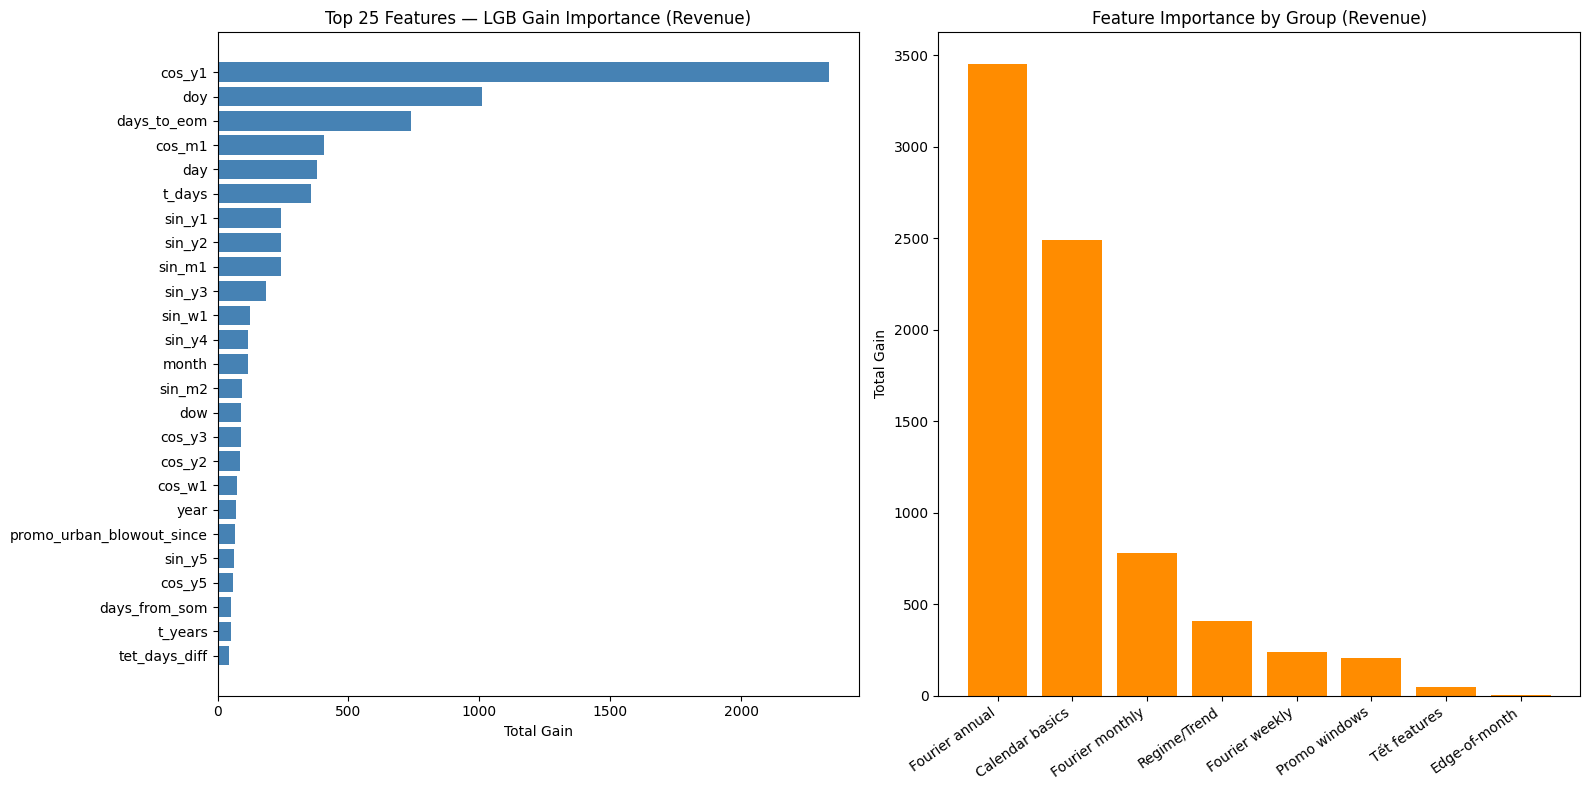

Top 10 most important features:
    feature  importance           group
     cos_y1 2333.717270  Fourier annual
        doy 1008.814846 Calendar basics
days_to_eom  739.093215 Calendar basics
     cos_m1  405.748078 Fourier monthly
        day  378.318449 Calendar basics
     t_days  358.101539    Regime/Trend
     sin_y1  243.998408  Fourier annual
     sin_y2  241.109203  Fourier annual
     sin_m1  240.354069 Fourier monthly
     sin_y3  183.214272  Fourier annual


In [181]:
# Feature importance: LGB gain-based
importance = bf_rev.feature_importance(importance_type='gain')
imp_df = (pd.DataFrame({
    'feature': cols, 
    'importance': importance
}).sort_values('importance', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 25 features
top25 = imp_df.head(25)
axes[0].barh(top25['feature'][::-1], top25['importance'][::-1], color='steelblue')
axes[0].set_title('Top 25 Features — LGB Gain Importance (Revenue)', fontsize=12)
axes[0].set_xlabel('Total Gain')

# Feature group summary
def feature_group(f):
    if f.startswith('sin_y') or f.startswith('cos_y'): return 'Fourier annual'
    if f.startswith('sin_w') or f.startswith('cos_w'): return 'Fourier weekly'
    if f.startswith('sin_m') or f.startswith('cos_m'): return 'Fourier monthly'
    if f.startswith('tet'):  return 'Tết features'
    if f.startswith('promo'): return 'Promo windows'
    if f.startswith('hol'):   return 'Holidays'
    if f.startswith('is_last') or f.startswith('is_first'): return 'Edge-of-month'
    if 'regime' in f or 't_days' in f or 't_years' in f: return 'Regime/Trend'
    return 'Calendar basics'

imp_df['group'] = imp_df['feature'].apply(feature_group)
group_imp = imp_df.groupby('group')['importance'].sum().sort_values(ascending=False)
axes[1].bar(range(len(group_imp)), group_imp.values, color='darkorange')
axes[1].set_xticks(range(len(group_imp)))
axes[1].set_xticklabels(group_imp.index, rotation=35, ha='right')
axes[1].set_title('Feature Importance by Group (Revenue)', fontsize=12)
axes[1].set_ylabel('Total Gain')

plt.tight_layout()
plt.savefig(OUT_DIR/'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(imp_df[['feature','importance','group']].head(10).to_string(index=False))

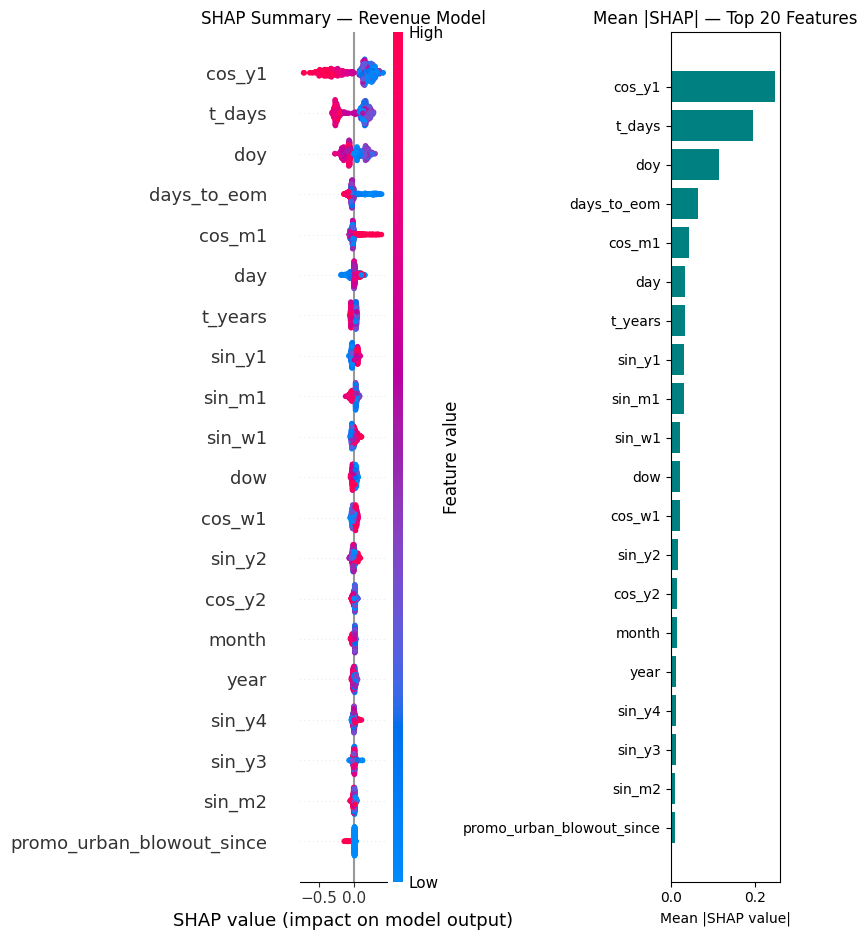

In [182]:
# SHAP value analysis
if SHAP_OK:
    # Use a representative 500-row sample for SHAP (full dataset is slow)
    np.random.seed(SEED)
    sample_idx = np.random.choice(len(X_tr), size=min(500, len(X_tr)), replace=False)
    X_sample   = X_tr[sample_idx]

    explainer  = shap.TreeExplainer(bf_rev)
    shap_vals  = explainer.shap_values(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Beeswarm summary
    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_sample, feature_names=cols,
                      max_display=20, show=False)
    axes[0].set_title('SHAP Summary — Revenue Model', fontsize=12)

    # Bar chart of mean |SHAP|
    mean_shap = np.abs(shap_vals).mean(axis=0)
    shap_df   = (pd.DataFrame({'feature': cols, 'mean_abs_shap': mean_shap})
                 .sort_values('mean_abs_shap', ascending=False).head(20))
    axes[1].barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1],
                 color='teal')
    axes[1].set_title('Mean |SHAP| — Top 20 Features', fontsize=12)
    axes[1].set_xlabel('Mean |SHAP value|')

    plt.tight_layout()
    plt.savefig(OUT_DIR/'shap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('SHAP not available — run: pip install shap')

## 8 — Forecast Visualisation


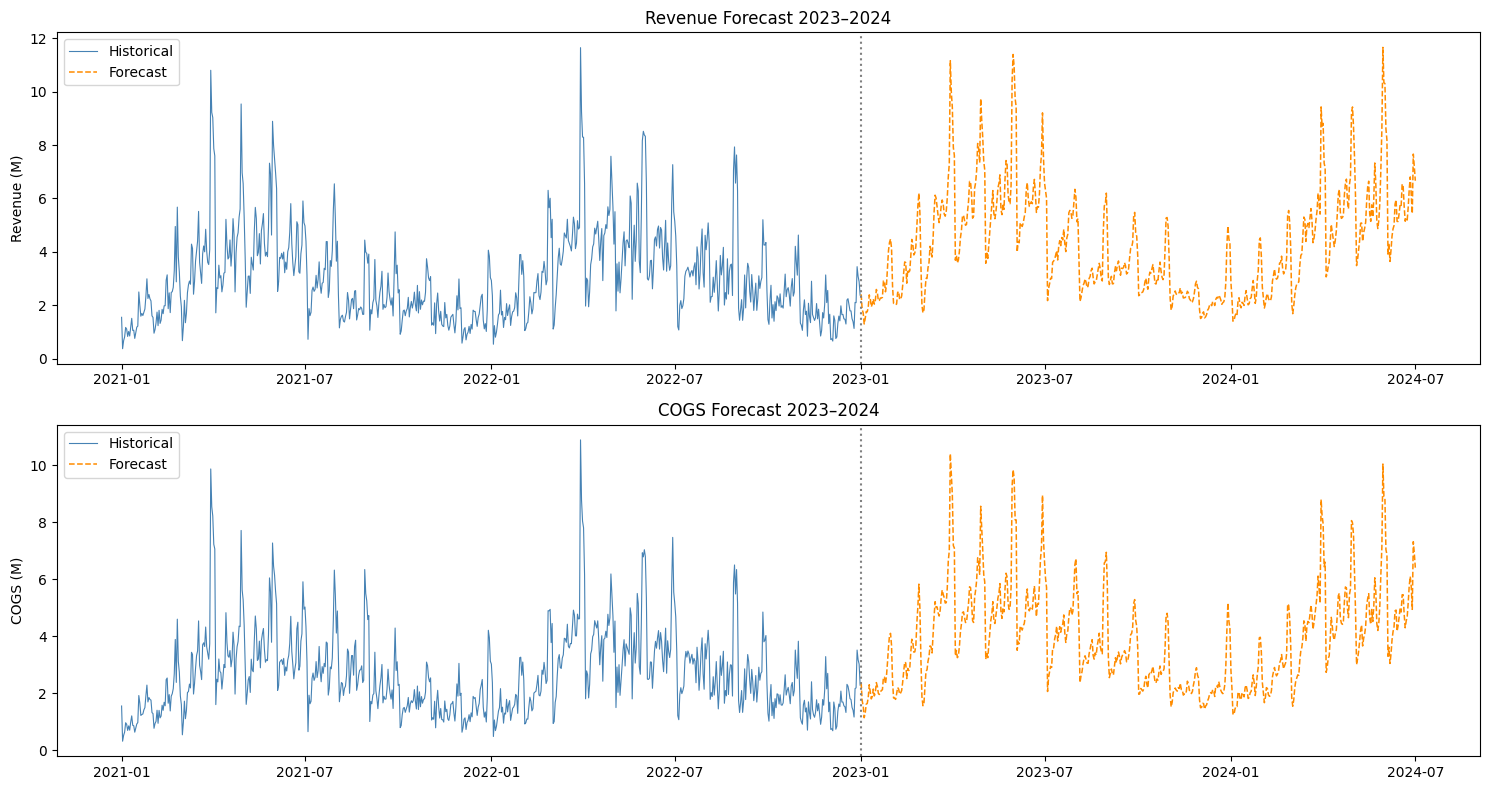

forecast_plot.png saved


In [183]:
fig, axes = plt.subplots(2,1, figsize=(15,8))
hist_tail = sales[sales.Y>=2021]
sub_plot  = main_sub.copy()
sub_plot['Date'] = pd.to_datetime(sub_plot['Date'])

for ax, col, title in [
    (axes[0],'Revenue','Revenue Forecast 2023–2024'),
    (axes[1],'COGS',   'COGS Forecast 2023–2024'),
]:
    ax.plot(hist_tail['Date'], hist_tail[col]/1e6, lw=0.8, color='steelblue', label='Historical')
    ax.plot(sub_plot['Date'],  sub_plot[col]/1e6,  lw=1.1, color='darkorange', ls='--', label='Forecast')
    ax.axvline(pd.Timestamp('2023-01-01'), color='gray', ls=':', lw=1.5)
    ax.set_title(title,fontsize=12); ax.set_ylabel(f'{col} (M)'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR/'forecast_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('forecast_plot.png saved')